# Geneformer: extract cell embeddings and calculate NMI against cell types

This notebook runs a simple Geneformer workflow:

1. Load an `.h5ad` file.
2. Prepare it for Geneformer tokenization.
3. Tokenize cells.
4. Extract Geneformer cell embeddings.
5. Cluster the embeddings.
6. Calculate NMI between clusters and known cell-type labels.

**Important:** Geneformer expects raw counts without HVG feature selection. Do not run `normalize_total`, `log1p`, `scale`, HVG selection, PCA, or Harmony before tokenization.


## 0. Install dependencies

Run this only once per environment. If you already installed Geneformer, skip this cell.

> Geneformer can be sensitive to Python / PyTorch / Transformers versions. For reproducibility, I recommend creating a fresh environment for Geneformer.


In [1]:
# Option A: install Geneformer from GitHub
# !pip install git+https://github.com/ctheodoris/Geneformer.git

# Common scientific dependencies
# !pip install scanpy anndata scikit-learn pandas numpy scipy matplotlib leidenalg igraph datasets transformers

## 1. Configure paths and columns

Edit these values for your dataset.

- `H5AD_PATH`: input AnnData file.
- `CELL_TYPE_COL`: the column in `adata.obs` containing known cell-type labels.
- `MODEL_DIR`: local path to the downloaded Geneformer model directory.
- `GENE_ID_SOURCE`: set to `"var_names"` if `adata.var_names` are already Ensembl IDs; otherwise set to the column in `adata.var` containing Ensembl IDs.


In [2]:
from pathlib import Path

# -----------------------------
# User settings
# -----------------------------
H5AD_PATH = Path("/home/haitham/mnt/DATA/brca_full/brca_cells_only_3000cell_4096gene.h5ad")

# Known cell type column in adata.obs
CELL_TYPE_COL = "cell_types"

# Optional obs columns to preserve through tokenization and embedding extraction
OBS_COLUMNS_TO_KEEP = [
    CELL_TYPE_COL,
    "donor_id",
    "batch",
]

# Local Geneformer model directory
# Example after downloading from HuggingFace:
# MODEL_DIR = Path("/mnt/models/Geneformer/geneformer-12L-30M")
# MODEL_DIR = Path("/mnt/models/Geneformer/Geneformer-V2-104M")
# MODEL_DIR = Path("/home/haitham/mnt/MODELS/Geneformer/Geneformer-V2-104M/")
# DICT_DIR = Path("/home/haitham/mnt/MODELS/Geneformer/gf_dicts_v2")

MODEL_DIR = Path("/home/haitham/mnt/MODELS/Geneformer/Geneformer-V1-10M")
DICT_DIR = Path("/home/haitham/mnt/MODELS/Geneformer/gf_dicts_v1")

# Geneformer V1 dict files (30M)
token_dictionary_file = str(DICT_DIR / "token_dictionary_gc30M.pkl")
gene_mapping_file = str(DICT_DIR / "ensembl_mapping_dict_gc30M.pkl")
gene_median_file = str(DICT_DIR / "gene_median_dictionary_gc30M.pkl")

# If you are using the Geneformer V1 dict files, we must avoid Geneformer's
# internal V1 auto-overrides (which point to bundled assets).
TOKENIZER_MODEL_VERSION = "V2"  # do not override our custom file paths
TOKENIZER_MODEL_INPUT_SIZE = 2048
TOKENIZER_SPECIAL_TOKEN = False

# Geneformer model series (for your weights); keep V1 for V1 models
MODEL_VERSION = "V1"

# Ensembl IDs
# Use "var_names" if adata.var_names are Ensembl IDs.
# Otherwise use a column name in adata.var, e.g. "ensembl_id".
GENE_ID_SOURCE = "var_names"

# Output directories
WORK_DIR = Path("/home/haitham/mnt/geneformer_run")
PREPARED_DIR = WORK_DIR / "prepared_h5ad"
TOKENIZED_DIR = WORK_DIR / "tokenized"
EMB_DIR = WORK_DIR / "embeddings"

for d in [WORK_DIR, PREPARED_DIR, TOKENIZED_DIR, EMB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PREPARED_H5AD = PREPARED_DIR / "geneformer_ready.h5ad"
TOKEN_PREFIX = "dataset"
EMB_PREFIX = "geneformer"


## 2. Load and prepare AnnData for Geneformer

Geneformer requires:

- raw count matrix in `adata.X`;
- `adata.var["ensembl_id"]`;
- `adata.obs["n_counts"]`;
- optional `adata.obs["filter_pass"]`.

This cell tries to use `adata.raw` if it exists, because many processed h5ad files store log-normalized or HVG-filtered data in `adata.X` and raw counts in `adata.raw`.


In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

adata = sc.read_h5ad(H5AD_PATH)
print(adata)

# If raw exists, use it as the source of counts.
# Comment this out if you are sure adata.X already contains raw counts with all genes.
if adata.raw is not None:
    print("Using adata.raw.to_adata() as Geneformer input.")
    adata = adata.raw.to_adata()
else:
    print("No adata.raw found. Assuming adata.X contains raw counts.")

# Make X sparse CSR for efficient storage/processing
if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)
else:
    adata.X = adata.X.tocsr()

# Geneformer requires total counts per cell in obs["n_counts"]
adata.obs["n_counts"] = np.asarray(adata.X.sum(axis=1)).ravel().astype(int)

# Optional: define cells to tokenize
# Here, we keep cells with non-zero total counts and non-missing cell type labels.
adata.obs["filter_pass"] = (
    (adata.obs["n_counts"] > 0) &
    (adata.obs[CELL_TYPE_COL].notna())
).astype(int)

# Geneformer requires Ensembl IDs in var["ensembl_id"]
if GENE_ID_SOURCE == "var_names":
    adata.var["ensembl_id"] = adata.var_names.astype(str)
else:
    adata.var["ensembl_id"] = adata.var[GENE_ID_SOURCE].astype(str)

# Remove Ensembl version suffix if present, e.g. ENSG00000141510.18 -> ENSG00000141510
adata.var["ensembl_id"] = adata.var["ensembl_id"].str.replace(r"\.\d+$", "", regex=True)

# Keep only needed obs columns if they exist
existing_obs_cols = [c for c in OBS_COLUMNS_TO_KEEP if c in adata.obs.columns]
missing_obs_cols = [c for c in OBS_COLUMNS_TO_KEEP if c not in adata.obs.columns]
print("Keeping obs columns:", existing_obs_cols)
if missing_obs_cols:
    print("Missing obs columns ignored:", missing_obs_cols)

# Geneformer can preserve these obs attributes during tokenization.
# We keep them in adata.obs.
adata.write_h5ad(PREPARED_H5AD)
print(f"Wrote: {PREPARED_H5AD}")
print(adata)


AnnData object with n_obs × n_vars = 87326 × 4096
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell_id', 'donor_id', 'timepoint', 'outcome', 'Cancer_type', 'cell_types', 'cohort', 'pre_post', 'donor_id_pre_post', 'donor_id_outcome', 'donor_id_cell_types', 'donor_id_cell_types_pre_post', 'sample_id_pre_post_outcome', 'enough_cells', 'Study_name', 'Primary_or_met', 'RNA_snn_res.0.8', 'seurat_clusters', 'ident', 'n_genes_by_counts', 'total_counts', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_name', 'hvg', 'log1p'
    obsm: 'PCA', 'UMAP'
    layers: 'counts', 'logcounts', 'scaledata'
No adata.raw found. Assuming adata.X contains raw counts.
Keeping obs columns: ['cell_types', 'donor_id']
Missing obs columns ignored: ['batch']
Wrote: /home/haitham/mnt/geneformer_run/prepared_h5ad/geneformer_ready.h5ad
AnnData object with n_obs × n_vars = 87326 × 4

In [4]:
np.min(adata.X), np.max(adata.X)

(np.float64(0.0), np.float64(9.050353287030438))

In [5]:
adata.var

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,ensembl_id
A2M,16543,1.256808,81.056043,109752.0,16543,True,1.137573,3.457010,0.800292,A2M
AADACL2-AS1,2260,0.046779,97.411996,4085.0,2260,True,0.077879,2.168685,0.670228,AADACL2-AS1
AARD,6232,0.241097,92.863523,21054.0,6232,True,0.279812,2.822963,1.321063,AARD
ABCA10,1634,0.027552,98.128851,2406.0,1634,True,0.055559,2.428896,1.105766,ABCA10
ABCA6,3717,0.072842,95.743536,6361.0,3717,True,0.122283,2.187060,0.700984,ABCA6
...,...,...,...,...,...,...,...,...,...,...
OR7C1,29,0.000366,99.966791,32.0,29,True,0.000794,2.694124,1.549700,OR7C1
POU6F2-AS2,15,0.000183,99.982823,16.0,15,True,0.000381,2.032513,0.442307,POU6F2-AS2
C20orf85,17,0.004214,99.980533,368.0,17,True,0.003735,3.767962,3.347076,C20orf85
SLC6A19,807,0.062937,99.075877,5496.0,807,True,0.027952,2.040715,0.456035,SLC6A19


In [6]:
def _map_ensembl_ids( adata, gene_to_ensembl):
    """
    Convert gene symbols (adata.var.index) -> ensembl ids (adata.var['ensembl_id'])
    and drop genes without an ensembl mapping.
    """
    adata.var["ensembl_id"] = adata.var.index.map(gene_to_ensembl)
    nan_idx = adata.var.ensembl_id.isna()
    if nan_idx.any():
        n_removed = int(nan_idx.sum())
        adata = adata[:, ~nan_idx]
        print(f"warning: genes dont have ensembl IDs {n_removed}. Genes without ensembl ID are REMOVED")
    return adata

In [7]:
import pickle

with open(gene_median_file, 'rb') as file:
    gene_med_df = pickle.load(file)

In [10]:
gene_mapping_file_v1 = '/home/haitham/mnt/MODELS/Geneformer/ensembl_mapping_dict_gc30M.pkl'
with open(gene_mapping_file_v1, 'rb') as file:
    gene_map_df_v1 = pickle.load(file)

list(gene_map_df_v1.values())[0:10]

['ENSG00000000003',
 'ENSG00000000005',
 'ENSG00000000419',
 'ENSG00000000457',
 'ENSG00000000460',
 'ENSG00000000938',
 'ENSG00000000971',
 'ENSG00000001036',
 'ENSG00000001084',
 'ENSG00000001167']

In [11]:

# gene_mapping_file = '/home/haitham/mnt/MODELS/Geneformer/gf_dicts_v1/ensembl_mapping_dict_gc30M.pkl'
gene_mapping_file = '/home/haitham/mnt/MODELS/Geneformer/gf_dicts_v2/ensembl_mapping_dict_gc104M.pkl'

In [12]:
with open(gene_mapping_file, 'rb') as file:
    gene_map_df = pickle.load(file)

In [13]:
list(gene_map_df.keys())[0:10]

['5S_RRNA',
 'RNA5-8SP10',
 '5_8S_RRNA',
 '7SK',
 'ABG',
 'GAB',
 'HYST2477',
 'A1BG',
 'A1BG-AS1',
 'NCRNA00181']

In [14]:
adata = _map_ensembl_ids(adata, gene_map_df)

In [15]:
adata.var

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm,ensembl_id
A2M,16543,1.256808,81.056043,109752.0,16543,True,1.137573,3.457010,0.800292,ENSG00000175899
AADACL2-AS1,2260,0.046779,97.411996,4085.0,2260,True,0.077879,2.168685,0.670228,ENSG00000242908
AARD,6232,0.241097,92.863523,21054.0,6232,True,0.279812,2.822963,1.321063,ENSG00000205002
ABCA10,1634,0.027552,98.128851,2406.0,1634,True,0.055559,2.428896,1.105766,ENSG00000154263
ABCA6,3717,0.072842,95.743536,6361.0,3717,True,0.122283,2.187060,0.700984,ENSG00000154262
...,...,...,...,...,...,...,...,...,...,...
NPIPA2,23,0.000263,99.973662,23.0,23,True,0.000504,2.173357,0.678050,ENSG00000254852
OR7C1,29,0.000366,99.966791,32.0,29,True,0.000794,2.694124,1.549700,ENSG00000127530
POU6F2-AS2,15,0.000183,99.982823,16.0,15,True,0.000381,2.032513,0.442307,ENSG00000233854
SLC6A19,807,0.062937,99.075877,5496.0,807,True,0.027952,2.040715,0.456035,ENSG00000174358


## 3. Tokenize cells with Geneformer

This converts each cell into Geneformer's ranked gene-token representation.


In [16]:
existing_obs_cols

['cell_types', 'donor_id']

In [17]:
MODEL_VERSION

'V1'

In [18]:
str(gene_median_file)

'/home/haitham/mnt/MODELS/Geneformer/gf_dicts_v1/gene_median_dictionary_gc30M.pkl'

In [19]:
gene_median_file

'/home/haitham/mnt/MODELS/Geneformer/gf_dicts_v1/gene_median_dictionary_gc30M.pkl'

In [20]:
with open(gene_median_file, "rb") as f:
   gene_median_dict = pickle.load(f)

In [22]:
TOKENIZER_MODEL_VERSION

'V2'

In [21]:
from geneformer import TranscriptomeTokenizer

# Map original obs column names to output attribute names in the tokenized dataset.
custom_attr_name_dict = {c: c for c in existing_obs_cols}



# IMPORTANT:
# Geneformer overrides file paths when model_version="V1".
# Use TOKENIZER_MODEL_VERSION="V2" to keep our explicit dict file paths,
# while still using V1-compatible settings (2048 + no <cls>/<eos> tokens).
tk = TranscriptomeTokenizer(
    custom_attr_name_dict=custom_attr_name_dict,
    nproc=8,
    model_version=TOKENIZER_MODEL_VERSION,
    model_input_size=TOKENIZER_MODEL_INPUT_SIZE,
    special_token=TOKENIZER_SPECIAL_TOKEN,
    token_dictionary_file=token_dictionary_file,
    gene_mapping_file=gene_mapping_file,
    gene_median_file=gene_median_file,
)

tk.tokenize_data(
    data_directory=str(PREPARED_DIR),
    output_directory=str(TOKENIZED_DIR),
    output_prefix=TOKEN_PREFIX,
    file_format="h5ad",
)

TOKENIZED_FILE = TOKENIZED_DIR / f"{TOKEN_PREFIX}.dataset"
print(f"Tokenized dataset should be here: {TOKENIZED_FILE}")


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizing /home/haitham/mnt/geneformer_run/prepared_h5ad/geneformer_ready.h5ad


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/geneformer/tokenizer.py:547: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


Creating dataset.
Tokenized dataset should be here: /home/haitham/mnt/geneformer_run/tokenized/dataset.dataset


## 4. Extract Geneformer cell embeddings

Notes:

- `emb_mode="cell"` returns one embedding vector per cell.
- Set `max_ncells=None` to process all cells.
- `emb_layer=-1` means the second-to-last layer in Geneformer’s API and is commonly used as a more general representation.
- Reduce `forward_batch_size` if you run out of GPU memory.


In [23]:
from geneformer import EmbExtractor

embex = EmbExtractor(
    model_type="Pretrained",
    num_classes=0,
    emb_mode="cell",
    max_ncells=None,
    emb_layer=-1,
    emb_label=existing_obs_cols,
    labels_to_plot=[],
    forward_batch_size=32,
    nproc=8,
    model_version=TOKENIZER_MODEL_VERSION,
    token_dictionary_file=token_dictionary_file,
)




In [24]:
embex

In [25]:
embs = embex.extract_embs(
    model_directory=str(MODEL_DIR),
    input_data_file=str(TOKENIZED_FILE),
    output_directory=str(EMB_DIR),
    output_prefix=EMB_PREFIX,
)


print(type(embs))

print(embs.shape)


100%|██████████| 2729/2729 [02:16<00:00, 19.97it/s]


<class 'pandas.core.frame.DataFrame'>
(87326, 258)


## 5. Load embeddings into AnnData

`EmbExtractor.extract_embs` usually returns a dataframe and/or writes a CSV file. This cell handles either case.


In [26]:
import glob

# Case 1: EmbExtractor returned a pandas DataFrame
if isinstance(embs, pd.DataFrame):
    emb_df = embs.copy()
else:
    # Case 2: load output CSV from disk
    csv_files = sorted(glob.glob(str(EMB_DIR / "*.csv")))
    print("CSV files found:", csv_files)
    if len(csv_files) == 0:
        raise FileNotFoundError("No embedding CSV found. Check EmbExtractor output directory.")
    emb_df = pd.read_csv(csv_files[0], index_col=0)

print(emb_df.head())
print(emb_df.shape)

# Identify numeric embedding columns
numeric_cols = emb_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of numeric embedding columns: {len(numeric_cols)}")

# Load prepared AnnData
adata_gf = sc.read_h5ad(PREPARED_H5AD)

# Keep only tokenized/filter_pass cells.
adata_gf = adata_gf[adata_gf.obs["filter_pass"].astype(bool)].copy()

# Try to align rows by index if possible.
# Otherwise assume same order as tokenized output.
if emb_df.index.isin(adata_gf.obs_names).all():
    adata_gf = adata_gf[emb_df.index].copy()
else:
    print("Embedding index does not fully match adata.obs_names; assuming same row order.")
    adata_gf = adata_gf[: emb_df.shape[0]].copy()

adata_gf.obsm["X_geneformer"] = emb_df[numeric_cols].to_numpy()

print(adata_gf)
print(adata_gf.obsm["X_geneformer"].shape)


          0         1         2         3         4         5         6  \
0  0.010294  0.061613 -0.020382  0.083074 -0.052852  0.122641 -0.032205   
1  0.001876  0.074671 -0.027287  0.086358 -0.052714  0.142980 -0.050686   
2 -0.007178  0.101012 -0.044620  0.087514 -0.042921  0.127475 -0.043919   
3 -0.001451  0.099289 -0.043771  0.105258 -0.060950  0.148280 -0.052764   
4 -0.005633  0.015325 -0.049835  0.101367 -0.047653  0.069633 -0.027077   

          7         8         9  ...       248       249       250       251  \
0  0.043691  0.031714 -0.098170  ...  0.058549  0.051585  0.057577  0.040970   
1  0.043229  0.044395 -0.096932  ...  0.035418  0.067025  0.045108  0.026258   
2  0.044342  0.051032 -0.093450  ...  0.010061  0.050849  0.044288  0.050521   
3  0.046140  0.031202 -0.082841  ...  0.028034  0.045303  0.053889  0.053451   
4  0.047705  0.046798 -0.107200  ...  0.022217  0.100642 -0.044264  0.051024   

        252       253       254       255   cell_types   donor_id  


## 6. Cluster Geneformer embeddings

This performs clustering directly on `X_geneformer`.

You can tune:

- `N_PCS`: number of PCs computed from embeddings before neighbors/clustering.
- `LEIDEN_RESOLUTION`: clustering granularity.


In [27]:
import scanpy as sc

N_PCS = 50
LEIDEN_RESOLUTION = 1.0

# PCA on Geneformer embeddings
sc.pp.pca(
    adata_gf,
    n_comps=min(N_PCS, adata_gf.obsm["X_geneformer"].shape[1]),
    use_highly_variable=False,
    svd_solver="arpack",
    layer=None,
)

# Scanpy stores PCA from adata.X by default. We want PCA of Geneformer embeddings.
# A clearer route is to temporarily set X to the embedding matrix.
adata_tmp = sc.AnnData(
    X=adata_gf.obsm["X_geneformer"],
    obs=adata_gf.obs.copy(),
)

sc.pp.pca(
    adata_tmp,
    n_comps=min(N_PCS, adata_tmp.n_vars - 1, adata_tmp.n_obs - 1),
    svd_solver="arpack",
)
sc.pp.neighbors(adata_tmp, use_rep="X_pca", n_neighbors=15)
sc.tl.leiden(adata_tmp, resolution=LEIDEN_RESOLUTION, key_added="geneformer_leiden")
sc.tl.umap(adata_tmp)

adata_gf.obs["geneformer_leiden"] = adata_tmp.obs["geneformer_leiden"].astype(str).values
adata_gf.obsm["X_umap_geneformer"] = adata_tmp.obsm["X_umap"]

adata_gf.obs["geneformer_leiden"].value_counts().head()


/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/tmp/ipykernel_7320/1843466042.py:28: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_tmp, resolution=LEIDEN_RESOLUTION, key_added="geneformer_leiden")


geneformer_leiden
0    11247
1     9798
2     8745
3     8612
4     6970
Name: count, dtype: int64

## 7. Calculate NMI between clusters and known cell types

NMI measures agreement between unsupervised clusters and known cell-type labels. Higher is better, with 1.0 meaning perfect agreement.


In [28]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

valid = (
    adata_gf.obs[CELL_TYPE_COL].notna() &
    adata_gf.obs["geneformer_leiden"].notna()
)

y_true = adata_gf.obs.loc[valid, CELL_TYPE_COL].astype(str)
y_cluster = adata_gf.obs.loc[valid, "geneformer_leiden"].astype(str)

nmi = normalized_mutual_info_score(y_true, y_cluster)
ari = adjusted_rand_score(y_true, y_cluster)

print(f"Number of cells used: {valid.sum():,}")
print(f"NMI Geneformer Leiden clusters vs {CELL_TYPE_COL}: {nmi:.4f}")
print(f"ARI Geneformer Leiden clusters vs {CELL_TYPE_COL}: {ari:.4f}")


Number of cells used: 87,326
NMI Geneformer Leiden clusters vs cell_types: 0.0081
ARI Geneformer Leiden clusters vs cell_types: 0.0027


In [29]:
adata_gf.obs['batch'] = adata_gf.obs['donor_id'] 
adata_gf.obs['label'] = adata_gf.obs['cell_types'] 

In [36]:
adata_gf

AnnData object with n_obs × n_vars = 87326 × 4096
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell_id', 'donor_id', 'timepoint', 'outcome', 'Cancer_type', 'cell_types', 'cohort', 'pre_post', 'donor_id_pre_post', 'donor_id_outcome', 'donor_id_cell_types', 'donor_id_cell_types_pre_post', 'sample_id_pre_post_outcome', 'enough_cells', 'Study_name', 'Primary_or_met', 'RNA_snn_res.0.8', 'seurat_clusters', 'ident', 'n_genes_by_counts', 'total_counts', 'n_genes', 'n_counts', 'filter_pass', 'geneformer_leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ensembl_id'
    uns: 'X_name', 'hvg', 'log1p', 'pca'
    obsm: 'PCA', 'UMAP', 'X_geneformer', 'X_pca', 'X_umap_geneformer'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaledata'

In [30]:
import os
import sys
sys.path.append('..')

In [31]:
from evaluation.eval import EmbeddingEvaluator

In [37]:
adata_gf.obs.label

BIOKEY_13_Pre_GCGGGTTCAATGAATG-1    Myeloid_cell
BIOKEY_13_On_GTCTCGTCACCATCCT-1      Cancer_cell
BIOKEY_13_Pre_TGGCTGGAGATCCGAG-1      Fibroblast
BIOKEY_13_Pre_TGAGCCGAGATGTGTA-1      Fibroblast
BIOKEY_13_Pre_GCGAGAAAGTGCGTGA-1      Fibroblast
                                        ...     
BIOKEY_24_Pre_GGGACCTTCTCGCTTG-1    Myeloid_cell
BIOKEY_24_On_AGTAGTCCACACAGAG-1       Fibroblast
BIOKEY_24_Pre_GTCGGGTGTTGATTGC-1          T_cell
BIOKEY_24_Pre_TACTCATTCTGCTTGC-1          T_cell
BIOKEY_24_On_TACCTTACAAGGTTTC-1     Myeloid_cell
Name: label, Length: 87326, dtype: category
Categories (8, object): ['B_cell', 'Cancer_cell', 'Endothelial_cell', 'Fibroblast', 'Mast_cell', 'Myeloid_cell', 'T_cell', 'pDC']

In [32]:
evaluator = EmbeddingEvaluator(adata_gf, embedding_key='X_geneformer', save_dir='.' )
ret_dict = evaluator.evaluate()

/home/haitham/scFM_eval/__try_things/../evaluation/eval.py:317: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/haitham/scFM_eval/.pixi/envs/geneformer/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: F

In [33]:
ret_dict

{'NMI_cluster/label': 0.004522895482862545,
 'ARI_cluster/label': np.float64(0.003612122214030944),
 'ASW_label': 0.4844826636835933,
 'graph_conn': np.float64(0.5545972836087347),
 'ASW_batch': 0.4877304872497916,
 'ASW_label/batch': np.float32(0.94875395),
 'batch_ASW': np.float32(0.94875395),
 'PCR_batch': np.float64(0.36892499564681014),
 'iLISI': 0.04294753819704056,
 'cLISI': 0.8369194865226746,
 'kBET': 0.0005897302560462097,
 'avg_bio': np.float64(0.1642058937934956),
 'knn_label_purity': 0.3033873073312522,
 'knn_batch_purity': 0.2711571200636898,
 'batch_pred_acc': 0.2798007557540364,
 'kNN_label_acc': 0.33310431695866255,
 'kNN_label_f1_macro': 0.13049949378356662}

## 8. Visualize UMAP colored by cell type and cluster

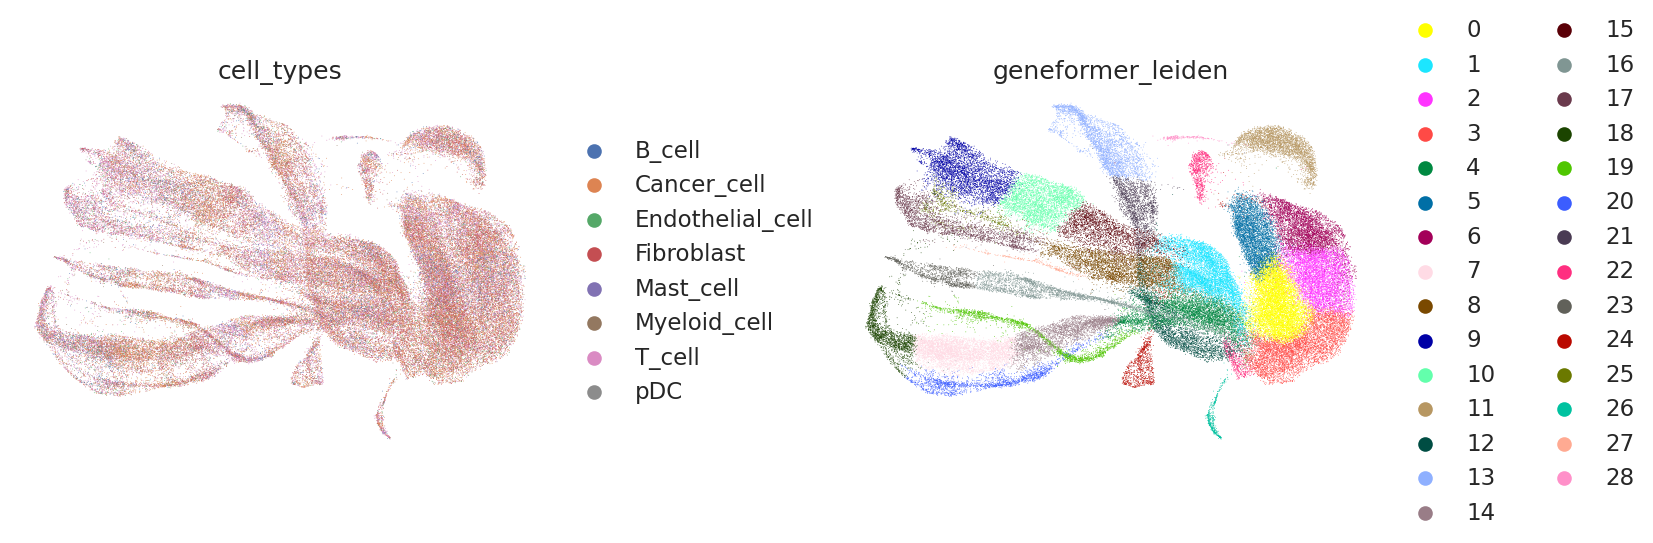

In [47]:
# Copy Geneformer UMAP into the standard key for plotting
adata_gf.obsm["X_umap"] = adata_gf.obsm["X_umap_geneformer"]

sc.pl.umap(
    adata_gf,
    color=[CELL_TYPE_COL, "geneformer_leiden"],
    wspace=0.4,
    frameon=False,
)


## 9. Save outputs

In [ ]:
OUTPUT_H5AD = WORK_DIR / "adata_with_geneformer_embeddings_clusters.h5ad"
OUTPUT_EMB = WORK_DIR / "geneformer_embeddings.csv"
OUTPUT_METRICS = WORK_DIR / "geneformer_nmi_metrics.csv"

adata_gf.write_h5ad(OUTPUT_H5AD)
pd.DataFrame(
    {
        "metric": ["NMI", "ARI"],
        "value": [nmi, ari],
        "cluster_key": ["geneformer_leiden", "geneformer_leiden"],
        "label_key": [CELL_TYPE_COL, CELL_TYPE_COL],
        "n_cells": [int(valid.sum()), int(valid.sum())],
        "leiden_resolution": [LEIDEN_RESOLUTION, LEIDEN_RESOLUTION],
    }
).to_csv(OUTPUT_METRICS, index=False)

pd.DataFrame(
    adata_gf.obsm["X_geneformer"],
    index=adata_gf.obs_names,
).to_csv(OUTPUT_EMB)

print(f"Saved AnnData: {OUTPUT_H5AD}")
print(f"Saved embeddings: {OUTPUT_EMB}")
print(f"Saved metrics: {OUTPUT_METRICS}")
